# XAI for Medical Diagnosis — Demo Notebook

This notebook walks through the full pipeline:
1. Data exploration
2. Preprocessing
3. Model training & evaluation
4. Single-patient prediction
5. SHAP explanations (summary + waterfall)
6. Batch prediction

## 0. Setup

In [1]:
# Install dependencies if needed
# !pip install pandas numpy scikit-learn shap matplotlib

import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Add src/ to the path so we can import our modules directly
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_PATH  = os.path.join(REPO_ROOT, 'src')
sys.path.insert(0, SRC_PATH)

DATA_PATH    = os.path.join(REPO_ROOT, 'data', 'sample_patient_data.csv')
RESULTS_PATH = os.path.join(REPO_ROOT, 'results')

print('Repo root:', REPO_ROOT)
print('Data file:', DATA_PATH)

Repo root: /home/runner/work/Explainable-Artificial-Intelligence-XAI-for-Medical-Diagnosis/Explainable-Artificial-Intelligence-XAI-for-Medical-Diagnosis
Data file: /home/runner/work/Explainable-Artificial-Intelligence-XAI-for-Medical-Diagnosis/Explainable-Artificial-Intelligence-XAI-for-Medical-Diagnosis/data/sample_patient_data.csv


## 1. Data Exploration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(10)

Shape: (100, 7)


,patient_id,heart_rate,blood_pressure,spo2,temperature,diagnosis,status
0,1,72,120,98,36.6,0,Stable
1,2,88,135,96,37.2,0,Stable
2,3,105,150,93,38.1,1,At Risk
3,4,115,160,90,38.8,1,Critical
4,5,65,118,99,36.4,0,Stable
5,6,78,125,97,36.9,0,Stable
6,7,92,140,94,37.5,1,At Risk
7,8,120,170,88,39.2,1,Critical
8,9,68,115,99,36.3,0,Stable
9,10,82,128,97,37.0,0,Stable


In [3]:
df.describe()

,patient_id,heart_rate,blood_pressure,spo2,temperature,diagnosis
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,94.310000,142.530000,93.280000,37.726000,0.500000
std,29.011492,21.981487,21.970345,4.915611,1.198199,0.502519
min,1.000000,63.000000,113.000000,82.000000,36.000000,0.000000
25%,25.750000,75.500000,123.750000,90.000000,36.775000,0.000000
50%,50.500000,90.500000,138.000000,94.500000,37.450000,0.500000
75%,75.250000,112.000000,158.500000,97.250000,38.575000,1.000000
max,100.000000,136.000000,186.000000,99.000000,40.300000,1.000000


In [4]:
print('Missing values per column:')
print(df.isnull().sum())

print('\nStatus distribution:')
print(df['status'].value_counts())

Missing values per column:
patient_id        0
heart_rate        0
blood_pressure    0
spo2              0
temperature       0
diagnosis         0
status            0
dtype: int64

Status distribution:
status
Stable      50
At Risk     25
Critical    25
Name: count, dtype: int64


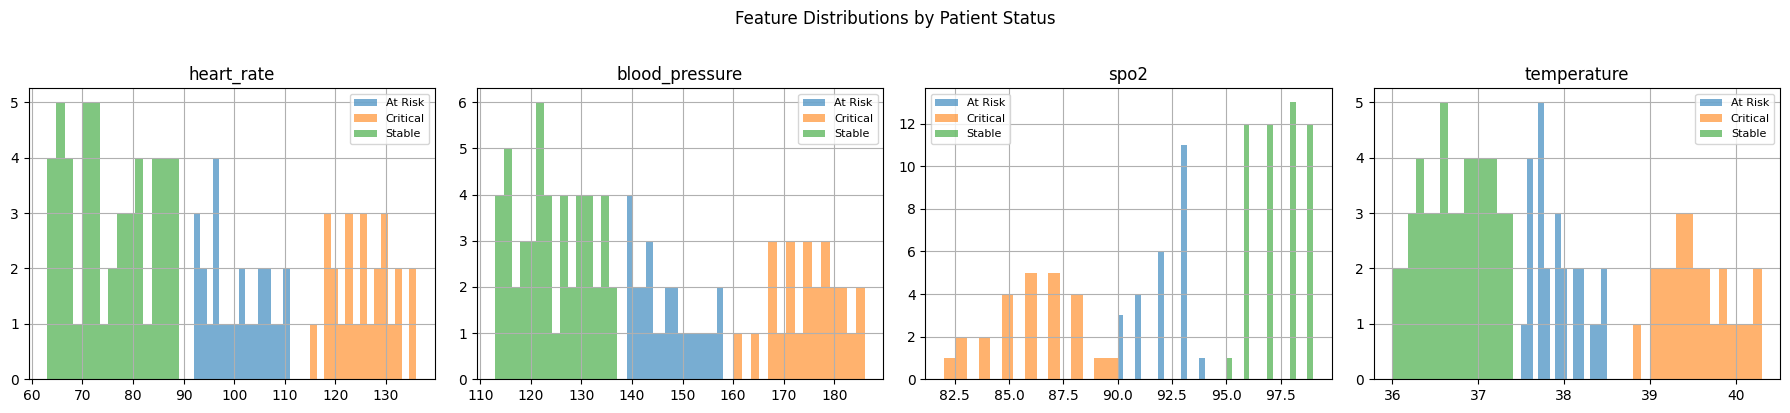

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
features = ['heart_rate', 'blood_pressure', 'spo2', 'temperature']

for ax, feat in zip(axes, features):
    for status, grp in df.groupby('status'):
        grp[feat].hist(ax=ax, alpha=0.6, label=status, bins=15)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Patient Status', y=1.02)
plt.tight_layout()
plt.show()

## 2. Preprocessing

In [6]:
from preprocessing import preprocess

data = preprocess(DATA_PATH)

print('Training set size :', len(data['X_train']))
print('Test set size     :', len(data['X_test']))
print('Feature columns   :', data['feature_names'])
data['X_train'].head()

Training set size : 80
Test set size     : 20
Feature columns   : ['heart_rate', 'blood_pressure', 'spo2', 'temperature']


,heart_rate,blood_pressure,spo2,temperature
0,0.287671,0.246575,0.823529,0.279070
1,0.397260,0.369863,0.705882,0.348837
2,0.547945,0.479452,0.588235,0.465116
3,0.465753,0.410959,0.647059,0.395349
4,0.589041,0.534247,0.529412,0.511628


## 3. Model Training & Evaluation

In [7]:
from model import train_and_evaluate

results = train_and_evaluate(data)
print('Models trained successfully.')

Models trained successfully.


In [8]:
diag_metrics   = results['diag_metrics']
status_metrics = results['status_metrics']

print('=== DIAGNOSIS MODEL ===')
print(f"Accuracy : {diag_metrics['accuracy']:.4f}")
print(diag_metrics['report'])

print('=== STATUS MODEL ===')
print(f"Accuracy : {status_metrics['accuracy']:.4f}")
print(status_metrics['report'])

# Cross-validation results
dcv = results['diag_cv']
scv = results['status_cv']
print('=== CROSS-VALIDATION (5-fold) ===')
print(f"Diagnosis  CV: {dcv['mean']:.4f} +/- {dcv['std']:.4f}  {[round(s,3) for s in dcv['cv_scores']]}")
print(f"Status     CV: {scv['mean']:.4f} +/- {scv['std']:.4f}  {[round(s,3) for s in scv['cv_scores']]}")


=== DIAGNOSIS MODEL ===
Accuracy : 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        10
    Positive       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

=== STATUS MODEL ===
Accuracy : 1.0000
              precision    recall  f1-score   support

      Stable       1.00      1.00      1.00        10
     At Risk       1.00      1.00      1.00         3
    Critical       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

=== CROSS-VALIDATION (5-fold) ===
Diagnosis  CV: 1.0000 +/- 0.0000  [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Status     CV: 1.0000 +/- 0.0000  [np.float64(1.0), np.fl

In [9]:
# Save metrics to results/metrics.txt
import os
os.makedirs(RESULTS_PATH, exist_ok=True)

with open(os.path.join(RESULTS_PATH, 'metrics.txt'), 'w') as f:
    f.write('=== DIAGNOSIS MODEL ===\n')
    f.write(f"Accuracy: {diag_metrics['accuracy']:.4f}\n")
    f.write(diag_metrics['report'])
    f.write('\n=== STATUS MODEL ===\n')
    f.write(f"Accuracy: {status_metrics['accuracy']:.4f}\n")
    f.write(status_metrics['report'])

print('Metrics saved to results/metrics.txt')

Metrics saved to results/metrics.txt


## 4. Single-Patient Prediction

In [10]:
from prediction import predict_single, format_prediction_report

sample_patient = {
    'heart_rate':     110,
    'blood_pressure': 155,
    'spo2':           91,
    'temperature':    38.4,
}

prediction = predict_single(
    results['diag_model'],
    results['status_model'],
    data['scaler'],
    sample_patient,
)

print(format_prediction_report(prediction))

  PATIENT PREDICTION REPORT
  Diagnosis : Positive
  Status    : At Risk

  Diagnosis probabilities:
    Negative  : 0.00%
    Positive  : 100.00%

  Status probabilities:
    Stable    : 0.00%
    At Risk   : 100.00%
    Critical  : 0.00%


## 5. SHAP Explanations

In [11]:
import shap
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend for saving plots
import matplotlib.pyplot as plt

from explainability import (
    compute_shap_values,
    plot_summary,
    plot_waterfall,
    explain_single,
)

In [12]:
# Compute SHAP values for the diagnosis model on the test set
shap_vals_diag = compute_shap_values(results['diag_model'], data['X_test'])
print('SHAP values computed. Shape:', shap_vals_diag.values.shape)

SHAP values computed. Shape: (20, 4, 2)


SHAP plot saved to: /home/runner/work/Explainable-Artificial-Intelligence-XAI-for-Medical-Diagnosis/Explainable-Artificial-Intelligence-XAI-for-Medical-Diagnosis/results/shap_plots.png
Summary plot saved.


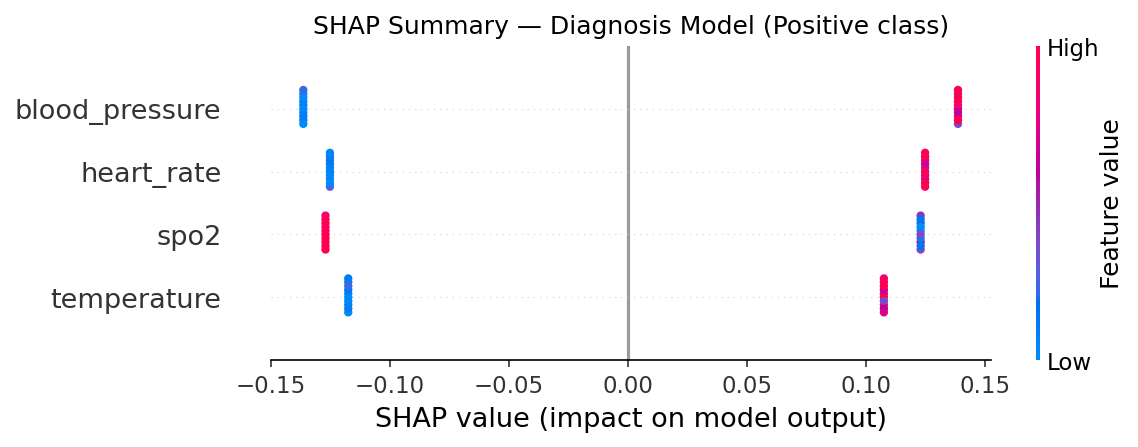

In [13]:
# --- Summary plot (global feature importance) ---
summary_path = os.path.join(RESULTS_PATH, 'shap_plots.png')
plot_summary(
    shap_vals_diag,
    data['X_test'],
    title='SHAP Summary — Diagnosis Model (Positive class)',
    save_path=summary_path,
    class_index=1,
)
print('Summary plot saved.')

# Display inline
from IPython.display import Image
Image(summary_path)

Waterfall plot saved to: /home/runner/work/Explainable-Artificial-Intelligence-XAI-for-Medical-Diagnosis/Explainable-Artificial-Intelligence-XAI-for-Medical-Diagnosis/results/shap_waterfall.png
Waterfall plot saved.


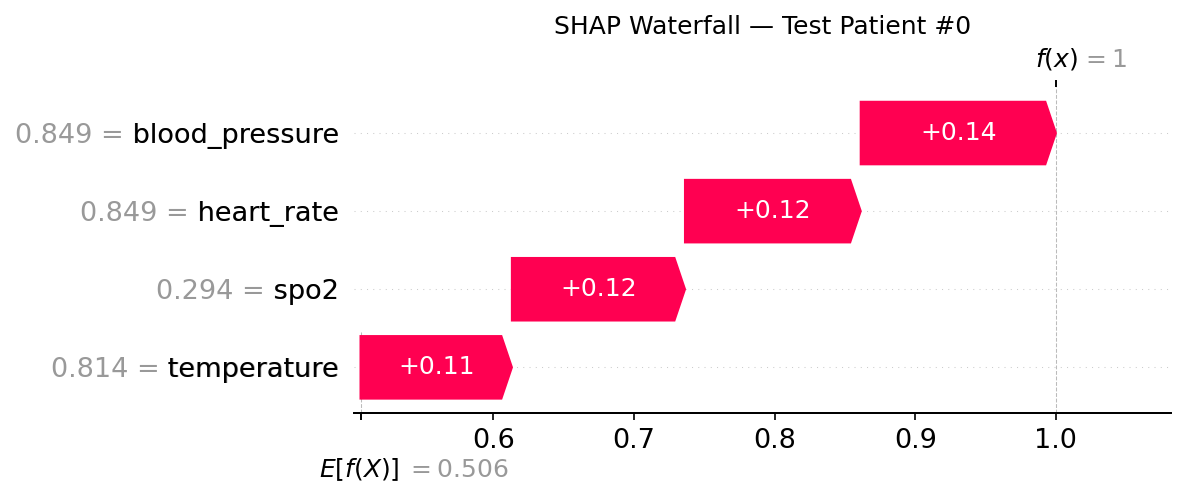

In [14]:
# --- Waterfall plot for a single test patient ---
waterfall_path = os.path.join(RESULTS_PATH, 'shap_waterfall.png')
plot_waterfall(
    shap_vals_diag,
    sample_index=0,
    title='SHAP Waterfall — Test Patient #0',
    save_path=waterfall_path,
    class_index=1,
)
print('Waterfall plot saved.')
Image(waterfall_path)

In [15]:
# --- Text explanation for the sample patient ---
import pandas as pd

sample_df = pd.DataFrame([sample_patient])
sample_scaled = pd.DataFrame(
    data['scaler'].transform(sample_df),
    columns=data['feature_names'],
)

text_exp = explain_single(
    results['diag_model'],
    sample_scaled,
    data['feature_names'],
)
print(text_exp)

Feature contributions (SHAP values):
  blood_pressure      : +0.1388  (↑ increases predicted risk)
  heart_rate          : +0.1249  (↑ increases predicted risk)
  spo2                : +0.1231  (↑ increases predicted risk)
  temperature         : +0.1076  (↑ increases predicted risk)


## 6. Batch Prediction

In [16]:
from prediction import predict_batch

# Run batch inference on the raw test features
# Re-load original (unscaled) test rows for display
raw_df = pd.read_csv(DATA_PATH)
test_indices = data['X_test'].index if hasattr(data['X_test'], 'index') else range(len(data['X_test']))

batch_results = predict_batch(
    results['diag_model'],
    results['status_model'],
    data['scaler'],
    data['X_test'],
)

print('Batch predictions (first 10 rows):')
batch_results[['heart_rate', 'blood_pressure', 'spo2', 'temperature',
               'predicted_diagnosis', 'predicted_status']].head(10)

Batch predictions (first 10 rows):


,heart_rate,blood_pressure,spo2,temperature,predicted_diagnosis,predicted_status
0,0.849315,0.849315,0.294118,0.813953,Negative,Stable
1,0.794521,0.794521,0.294118,0.744186,Negative,Stable
2,0.890411,0.890411,0.235294,0.837209,Negative,Stable
3,0.712329,0.643836,0.470588,0.651163,Negative,Stable
4,0.301370,0.260274,0.823529,0.255814,Negative,Stable
5,0.109589,0.136986,0.941176,0.139535,Negative,Stable
6,0.150685,0.095890,0.941176,0.116279,Negative,Stable
7,0.904110,0.904110,0.176471,0.860465,Negative,Stable
8,0.082192,0.082192,0.941176,0.093023,Negative,Stable
9,0.000000,0.000000,1.000000,0.000000,Negative,Stable


---
## Summary

| Step | Module | Output |
|------|--------|--------|
| Data loading & cleaning | `preprocessing.py` | Scaled train/test splits |
| Model training | `model.py` | Two RandomForest classifiers |
| Inference | `prediction.py` | Diagnosis + status + probabilities |
| Explainability | `explainability.py` | SHAP summary + waterfall plots |

The SHAP plots are saved in `results/` for inclusion in reports or presentations.